# 05 — SHAP Analysis (PADS Binary Classifier)

**Objective:** Explain the XGBoost model's predictions using SHAP values.

**Questions we're answering:**
1. Which features drive PD vs Healthy predictions globally?
2. Which tasks matter most?
3. Which sensor axes matter most (accel vs gyro, X/Y/Z)?
4. How does `age` interact with IMU features?
5. For a specific subject — why did the model predict what it did?

**Input:** `xgb_pads_binary_04.pkl` + full dataset rebuilt from scratch here  
**No need to run nb04 first — this notebook is fully self-contained.**


In [1]:
# ── Ensure compatible versions before any imports ─────────────────────────
# XGBoost 3.x broke SHAP's TreeExplainer. Pin to 2.1.1.
# Run this cell ONCE, then restart kernel, then skip this cell.
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "xgboost==2.1.1", "--quiet"], check=True)
print("xgboost 2.1.1 installed — RESTART KERNEL NOW, then run from Cell 3 onward.")


xgboost 2.1.1 installed — RESTART KERNEL NOW, then run from Cell 3 onward.


In [2]:
pip install "numpy<2" "xgboost==2.1.1" "matplotlib>=3.7" "scipy>=1.10" "scikit-learn>=1.3" "pandas>=2.0" "shap==0.44.1"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import pickle
import warnings
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from scipy.stats import kurtosis, skew
from scipy.fft import rfft, rfftfreq
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

import xgboost as xgb_lib
print(f"XGBoost version : {xgb_lib.__version__}")
print(f"SHAP version    : {shap.__version__}")


XGBoost version : 2.1.1
SHAP version    : 0.44.1


In [4]:
# ── Paths ────────────────────────────────────────────────────────────────
BASE_DIR      = "../data/pads_preprocessed"
MOVEMENT_DIR  = os.path.join(BASE_DIR, "movement")
FILE_LIST_CSV = os.path.join(BASE_DIR, "file_list.csv")
MODEL_PATH    = "../models/xgb_pads_binary_04.pkl"

assert os.path.isdir(MOVEMENT_DIR),   f"Not found: {MOVEMENT_DIR}"
assert os.path.isfile(FILE_LIST_CSV), f"Not found: {FILE_LIST_CSV}"

# ── Constants ─────────────────────────────────────────────────────────────
FS         = 100
N_CHANNELS = 132
N_SAMPLES  = 488

TASKS = [
    "Relaxed1", "Relaxed2", "RelaxedTask1", "RelaxedTask2",
    "StretchHold", "HoldWeight", "DrinkGlas", "CrossArms",
    "TouchNose", "Entrainment1", "Entrainment2",
]
WRISTS  = ["LeftWrist", "RightWrist"]
SENSORS = ["Accelerometer", "Gyroscope"]
AXES    = ["X", "Y", "Z"]

CHANNEL_NAMES = [
    f"{task}_{wrist}_{sensor}_{axis}"
    for task   in TASKS
    for wrist  in WRISTS
    for sensor in SENSORS
    for axis   in AXES
]

FEAT_NAMES_PER_CHANNEL = [
    "mean", "std", "rms", "peak_amp", "kurtosis", "skewness",
    "tremor_power_ratio", "dom_freq", "spectral_entropy",
    "mean_freq", "zcr", "energy",
]
N_FEATS = len(FEAT_NAMES_PER_CHANNEL)

KEEP_TASKS = [
    "TouchNose", "Entrainment1", "Entrainment2", "CrossArms",
    "DrinkGlas", "HoldWeight", "StretchHold", "RelaxedTask1", "RelaxedTask2",
]
BEST_THRESHOLD = 0.84

# ── Feature extractor ─────────────────────────────────────────────────────
def extract_features_from_signal(signal, fs=FS):
    feats = []
    feats.append(np.mean(signal))
    feats.append(np.std(signal))
    feats.append(np.sqrt(np.mean(signal**2)))
    feats.append(np.max(np.abs(signal)))
    feats.append(float(kurtosis(signal, fisher=True)))
    feats.append(float(skew(signal)))
    n       = len(signal)
    freqs   = rfftfreq(n, d=1.0/fs)
    fft_mag = np.abs(rfft(signal)) / n
    total_power  = np.sum(fft_mag**2) + 1e-12
    tremor_mask  = (freqs >= 4) & (freqs <= 6)
    feats.append(np.sum(fft_mag[tremor_mask]**2) / total_power)
    feats.append(float(freqs[np.argmax(fft_mag)]))
    psd_norm = fft_mag**2 / total_power
    psd_norm = psd_norm[psd_norm > 0]
    feats.append(float(-np.sum(psd_norm * np.log(psd_norm))))
    feats.append(float(np.sum(freqs * fft_mag**2) / total_power))
    feats.append(float(np.sum(np.diff(np.sign(signal)) != 0) / n))
    feats.append(float(np.sum(signal**2)))
    return np.array(feats, dtype=np.float32)

def load_subject_features(subject_id):
    sid   = str(subject_id).zfill(3)
    fpath = os.path.join(MOVEMENT_DIR, f"{sid}_ml.bin")
    if not os.path.isfile(fpath):
        return None
    raw = np.fromfile(fpath, dtype=np.float64)
    if raw.size != N_CHANNELS * N_SAMPLES:
        return None
    data  = raw.reshape(N_CHANNELS, N_SAMPLES)
    feats = np.concatenate([extract_features_from_signal(data[ch]) for ch in range(N_CHANNELS)])
    return feats.astype(np.float32)

print("Config & helpers OK")


Config & helpers OK


In [5]:
# ── Load metadata ─────────────────────────────────────────────────────────
df_meta = pd.read_csv(FILE_LIST_CSV)
df_meta = df_meta[df_meta["label"].isin([0, 1])].reset_index(drop=True)

le_gender     = LabelEncoder().fit(df_meta["gender"].fillna("unknown"))
le_handedness = LabelEncoder().fit(df_meta["handedness"].fillna("unknown"))

# ── Build X, y, groups ────────────────────────────────────────────────────
all_X, all_y, all_groups = [], [], []

for _, row in df_meta.iterrows():
    sid   = str(row["id"]).zfill(3)
    label = int(row["label"])
    feats = load_subject_features(sid)
    if feats is None:
        continue
    age       = float(row["age"])       if pd.notna(row["age"])       else -1.0
    g_enc     = float(le_gender.transform(
                    [row["gender"]      if pd.notna(row["gender"])      else "unknown"])[0])
    h_enc     = float(le_handedness.transform(
                    [row["handedness"]  if pd.notna(row["handedness"])  else "unknown"])[0])
    all_X.append(np.concatenate([feats, [age, g_enc, h_enc]]))
    all_y.append(label)
    all_groups.append(sid)

X_full = np.vstack(all_X)
y      = np.array(all_y,      dtype=np.int32)
groups = np.array(all_groups, dtype=str)

# ── Task selection (drop Relaxed1, Relaxed2) ──────────────────────────────
keep_ch_idx   = [i for i, ch in enumerate(CHANNEL_NAMES)
                 if any(ch.startswith(t) for t in KEEP_TASKS)]
keep_feat_idx = (
    [i * N_FEATS + f for i in keep_ch_idx for f in range(N_FEATS)]
    + list(range(N_CHANNELS * N_FEATS, N_CHANNELS * N_FEATS + 3))
)
X = X_full[:, keep_feat_idx]

imu_feat_names = [
    f"{CHANNEL_NAMES[i]}__{feat}"
    for i in keep_ch_idx
    for feat in FEAT_NAMES_PER_CHANNEL
]
feature_names = imu_feat_names + ["age", "gender_enc", "handedness_enc"]

assert X.shape[1] == len(feature_names), f"Mismatch: X={X.shape[1]}, names={len(feature_names)}"

# ── Scale ─────────────────────────────────────────────────────────────────
scaler_shap = StandardScaler()
X_scaled    = scaler_shap.fit_transform(X)

print(f"X shape       : {X.shape}")
print(f"Features      : {len(feature_names)}")
print(f"Subjects      : {len(groups)}")
print(f"Label balance : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape       : (355, 1299)
Features      : 1299
Subjects      : 355
Label balance : {0: 79, 1: 276}


In [6]:
neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
spw       = neg_count / pos_count

clf_full = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, random_state=42,
    eval_metric="logloss", verbosity=0,
)
clf_full.fit(X_scaled, y)
print("clf_full trained ✅")

# ── SHAP (TreeExplainer works cleanly on XGBoost 2.1.1) ───────────────────
explainer   = shap.TreeExplainer(clf_full)
shap_values = explainer.shap_values(X_scaled)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f"SHAP values shape : {sv.shape}")
print(f"Expected          : {X_scaled.shape}")


clf_full trained ✅
SHAP values shape : (355, 1299)
Expected          : (355, 1299)


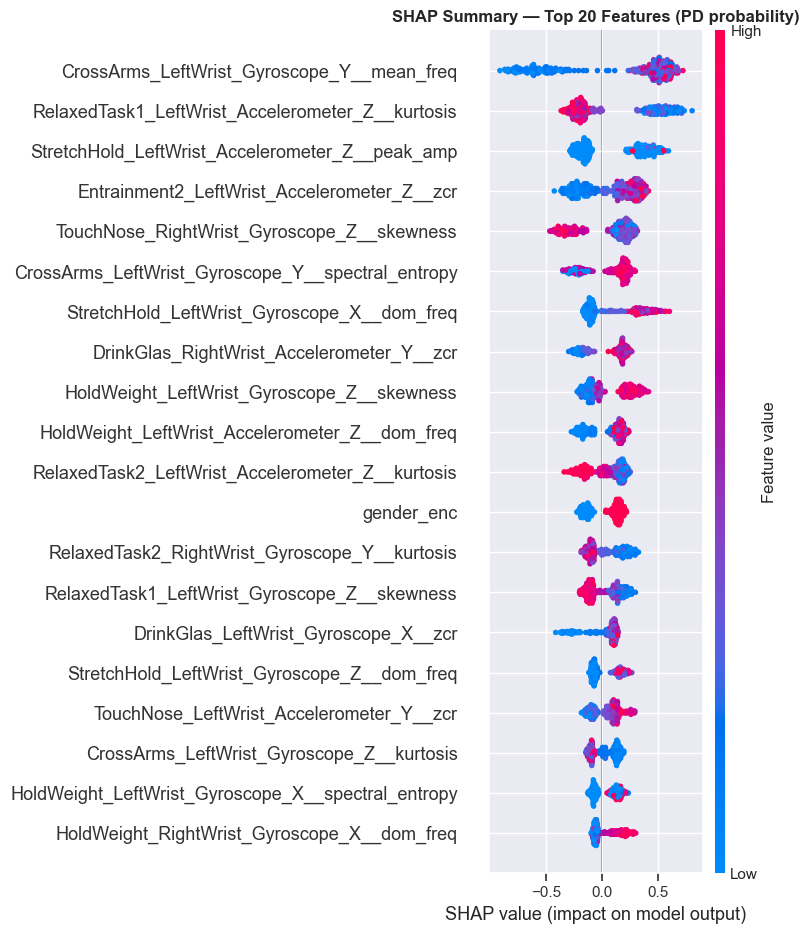

Saved → shap_summary_05.png


In [7]:
os.makedirs("../models", exist_ok=True)

shap.summary_plot(
    sv, X_scaled,
    feature_names=feature_names,
    max_display=20,
    show=False,
)
plt.title("SHAP Summary — Top 20 Features (PD probability)", fontweight="bold")
plt.tight_layout()
plt.savefig("../models/shap_summary_05.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → shap_summary_05.png")


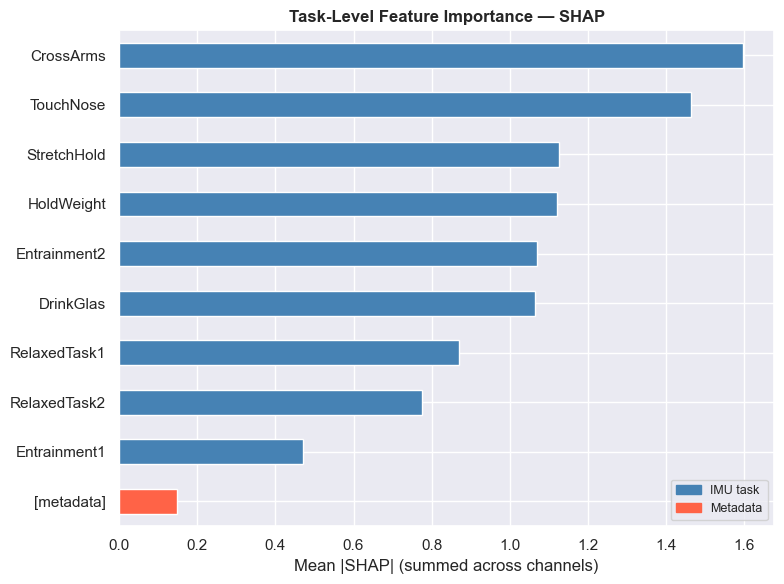

In [8]:
mean_abs_shap = np.abs(sv).mean(axis=0)

task_shap = {}
for i, ch in enumerate(CHANNEL_NAMES):
    if not any(ch.startswith(t) for t in KEEP_TASKS):
        continue
    task = ch.split("_")[0]
    start = keep_ch_idx.index(i) * N_FEATS if i in keep_ch_idx else None
    if start is None:
        continue
    task_shap[task] = task_shap.get(task, 0.0) + mean_abs_shap[start:start + N_FEATS].sum()

task_shap["[metadata]"] = mean_abs_shap[len(keep_ch_idx) * N_FEATS:].sum()

task_df = (pd.DataFrame.from_dict(task_shap, orient="index", columns=["shap_importance"])
             .sort_values("shap_importance", ascending=True))

fig, ax = plt.subplots(figsize=(8, 6))
bar_colors = ["tomato" if t == "[metadata]" else "steelblue" for t in task_df.index]
task_df["shap_importance"].plot(kind="barh", ax=ax, color=bar_colors)
ax.set_xlabel("Mean |SHAP| (summed across channels)")
ax.set_title("Task-Level Feature Importance — SHAP", fontweight="bold")
ax.legend(handles=[
    mpatches.Patch(color="steelblue", label="IMU task"),
    mpatches.Patch(color="tomato",    label="Metadata"),
], fontsize=9)
plt.tight_layout()
plt.savefig("../models/shap_task_importance_05.png", dpi=120, bbox_inches="tight")
plt.show()


In [19]:
# ── Sanity check: is 'age' dominating over IMU features? ─────────────────
meta_idx = len(keep_ch_idx) * N_FEATS
meta_names = ["age", "gender_enc", "handedness_enc"]

print("── Metadata SHAP contributions ──")
for i, name in enumerate(meta_names):
    print(f"  {name:20s}: mean|SHAP| = {np.abs(sv[:, meta_idx + i]).mean():.5f}")

# Compare against top-5 IMU features for context
mean_abs_imu = np.abs(sv[:, :meta_idx]).mean(axis=0)
top5_idx = np.argsort(mean_abs_imu)[::-1][:5]
print("\n── Top-5 IMU features for comparison ──")
for idx in top5_idx:
    print(f"  {imu_feat_names[idx]:60s}: {mean_abs_imu[idx]:.5f}")

── Metadata SHAP contributions ──
  age                 : mean|SHAP| = 0.00455
  gender_enc          : mean|SHAP| = 0.14212
  handedness_enc      : mean|SHAP| = 0.00000

── Top-5 IMU features for comparison ──
  CrossArms_LeftWrist_Gyroscope_Y__mean_freq                  : 0.52644
  RelaxedTask1_LeftWrist_Accelerometer_Z__kurtosis            : 0.33347
  StretchHold_LeftWrist_Accelerometer_Z__peak_amp             : 0.27057
  Entrainment2_LeftWrist_Accelerometer_Z__zcr                 : 0.23208
  TouchNose_RightWrist_Gyroscope_Z__skewness                  : 0.22920


In [20]:
# ── Verify task name extraction from channel names ────────────────────────
extracted_tasks = {ch.split("_")[0]
                   for ch in CHANNEL_NAMES
                   if any(ch.startswith(t) for t in KEEP_TASKS)}
print("Extracted task labels from CHANNEL_NAMES:")
print(sorted(extracted_tasks))
# Expected: CrossArms, DrinkGlas, Entrainment1, Entrainment2,
#           HoldWeight, RelaxedTask1, RelaxedTask2, StretchHold, TouchNose
assert extracted_tasks == set(KEEP_TASKS), \
    f"Task label mismatch!\n  Got:      {sorted(extracted_tasks)}\n  Expected: {sorted(KEEP_TASKS)}"
print("Task labels OK ✅")

Extracted task labels from CHANNEL_NAMES:
['CrossArms', 'DrinkGlas', 'Entrainment1', 'Entrainment2', 'HoldWeight', 'RelaxedTask1', 'RelaxedTask2', 'StretchHold', 'TouchNose']
Task labels OK ✅


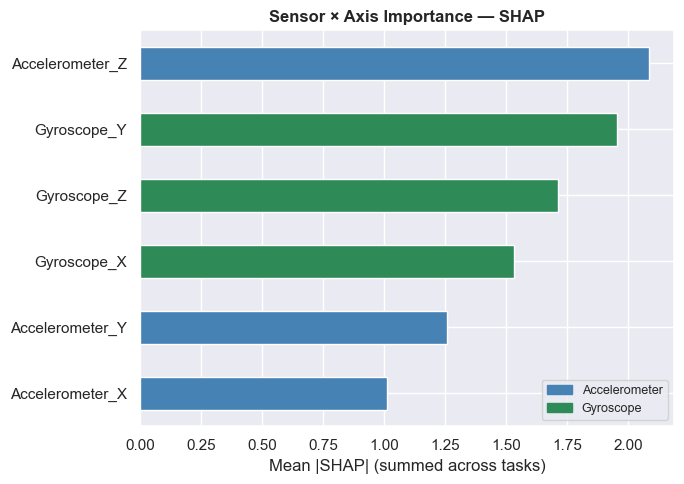

In [21]:
sensor_shap = {}
for idx_in_kept, i in enumerate(keep_ch_idx):
    ch     = CHANNEL_NAMES[i]
    parts  = ch.split("_")
    sensor = parts[-2]
    axis   = parts[-1]
    key    = f"{sensor}_{axis}"
    start  = idx_in_kept * N_FEATS
    sensor_shap[key] = sensor_shap.get(key, 0.0) + mean_abs_shap[start:start + N_FEATS].sum()

sensor_df = (pd.DataFrame.from_dict(sensor_shap, orient="index", columns=["shap_importance"])
               .sort_values("shap_importance", ascending=True))

fig, ax = plt.subplots(figsize=(7, 5))
palette = ["steelblue" if "Accel" in k else "seagreen" for k in sensor_df.index]
sensor_df["shap_importance"].plot(kind="barh", ax=ax, color=palette)
ax.set_xlabel("Mean |SHAP| (summed across tasks)")
ax.set_title("Sensor × Axis Importance — SHAP", fontweight="bold")
ax.legend(handles=[
    mpatches.Patch(color="steelblue", label="Accelerometer"),
    mpatches.Patch(color="seagreen",  label="Gyroscope"),
], fontsize=9)
plt.tight_layout()
plt.savefig("../models/shap_sensor_axis_05.png", dpi=120, bbox_inches="tight")
plt.show()


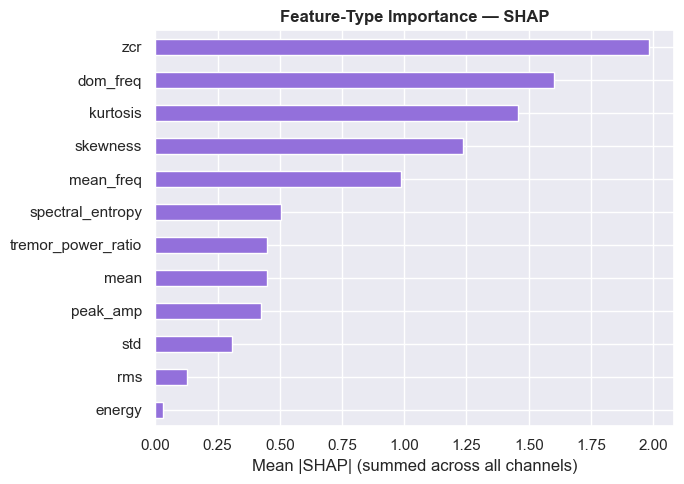

In [22]:
feat_type_shap = {f: 0.0 for f in FEAT_NAMES_PER_CHANNEL}

for idx_in_kept in range(len(keep_ch_idx)):
    for j, feat in enumerate(FEAT_NAMES_PER_CHANNEL):
        feat_type_shap[feat] += mean_abs_shap[idx_in_kept * N_FEATS + j]

feat_df = (pd.DataFrame.from_dict(feat_type_shap, orient="index", columns=["shap_importance"])
             .sort_values("shap_importance", ascending=True))

fig, ax = plt.subplots(figsize=(7, 5))
feat_df["shap_importance"].plot(kind="barh", ax=ax, color="mediumpurple")
ax.set_xlabel("Mean |SHAP| (summed across all channels)")
ax.set_title("Feature-Type Importance — SHAP", fontweight="bold")
plt.tight_layout()
plt.savefig("../models/shap_feat_type_05.png", dpi=120, bbox_inches="tight")
plt.show()


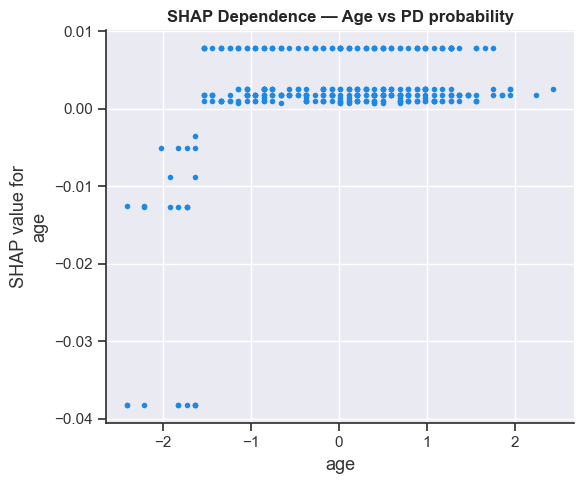

In [23]:
age_idx = feature_names.index("age")

shap.dependence_plot(
    age_idx,
    sv,
    X_scaled,
    feature_names=feature_names,
    interaction_index=None,
    show=False,
)
plt.title("SHAP Dependence — Age vs PD probability", fontweight="bold")
plt.tight_layout()
plt.savefig("../models/shap_age_dependence_05.png", dpi=120, bbox_inches="tight")
plt.show()


In [24]:
RES_CACHE = "../models/res_xgb_loso_04.csv"

if os.path.isfile(RES_CACHE):
    res_xgb = pd.read_csv(RES_CACHE)
    print(f"Loaded res_xgb from cache ({len(res_xgb)} subjects) ✅")
else:
    print("Cache not found — running LOSO (this takes ~2-3 min)...")
    results = []
    for test_subject in np.unique(groups):
        train_mask = groups != test_subject
        test_mask  = groups == test_subject
        sc   = StandardScaler()
        Xtr  = sc.fit_transform(X[train_mask])
        Xte  = sc.transform(X[test_mask])
        m    = XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=spw, random_state=42,
            eval_metric="logloss", verbosity=0,
        )
        m.fit(Xtr, y[train_mask])
        prob = m.predict_proba(Xte)[:, 1][0]
        pred = int(prob >= BEST_THRESHOLD)
        results.append(dict(
            subject=test_subject,
            true_label=int(y[test_mask][0]),
            predicted_label=pred,
            prob_pd=prob,
            correct=int(pred == y[test_mask][0]),
        ))
    res_xgb = pd.DataFrame(results)
    res_xgb.to_csv(RES_CACHE, index=False)
    print(f"Done. res_xgb saved → {RES_CACHE} ✅")

print(f"Subjects: {len(res_xgb)}")


Loaded res_xgb from cache (355 subjects) ✅
Subjects: 355


In [25]:
# ── Normalise subject IDs (CSV round-trip converts to float/int) ──────────
res_xgb["subject"] = res_xgb["subject"].astype(int).astype(str).str.zfill(3)
assert set(res_xgb["subject"]).issubset(set(groups)), \
    f"Subject ID mismatch — check LOSO cache vs groups array"
print("Subject IDs normalised ✅")
print("Sample:", res_xgb["subject"].values[:5])

Subject IDs normalised ✅
Sample: <ArrowStringArray>
['001', '003', '004', '005', '006']
Length: 5, dtype: str


In [26]:
# Debug: check subject format mismatch
print("groups sample    :", groups[:5])
print("res_xgb sample   :", res_xgb["subject"].values[:5])
print("types            :", type(groups[0]), type(res_xgb["subject"].values[0]))

groups sample    : ['001' '003' '004' '005' '006']
res_xgb sample   : <ArrowStringArray>
['001', '003', '004', '005', '006']
Length: 5, dtype: str
types            : <class 'numpy.str_'> <class 'str'>


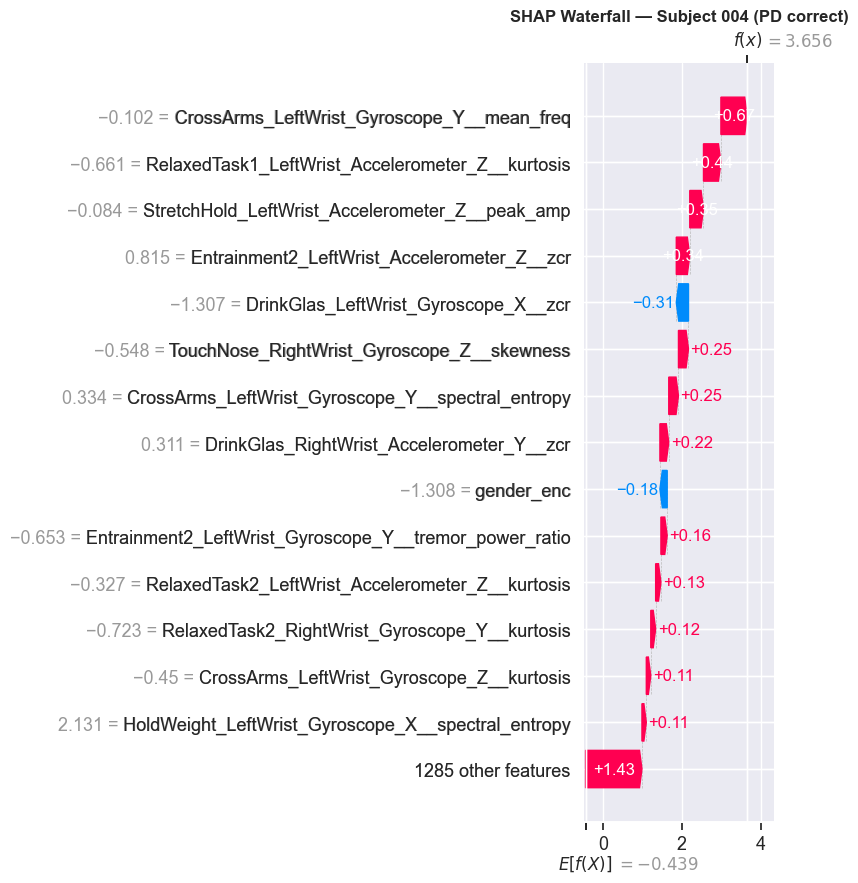

Saved → ../models/shap_waterfall_pd_correct_05.png


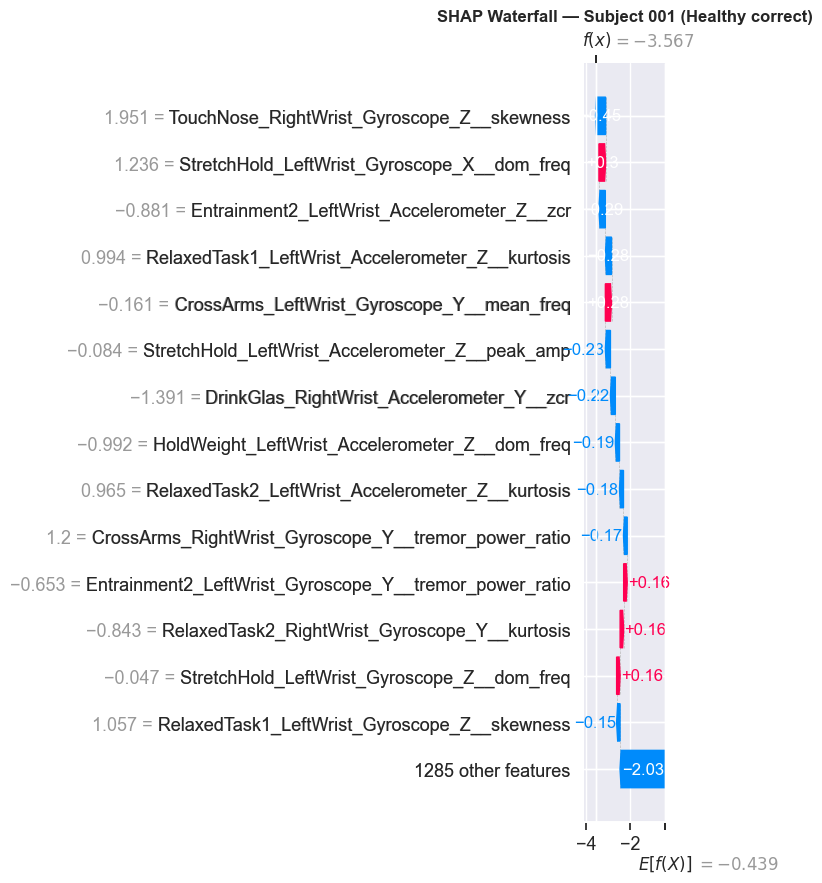

Saved → ../models/shap_waterfall_healthy_correct_05.png


In [27]:
# ── Waterfall: one correct PD, one correct Healthy ────────────────────────
correct_pd      = res_xgb[(res_xgb["true_label"] == 1) & (res_xgb["correct"] == 1)].iloc[0]
correct_healthy = res_xgb[(res_xgb["true_label"] == 0) & (res_xgb["correct"] == 1)].iloc[0]

base_val = (explainer.expected_value[1]
            if isinstance(explainer.expected_value, (list, np.ndarray))
            else explainer.expected_value)

groups_norm = np.array([str(g).zfill(3) for g in groups])  # already normalised but be safe

for label, row in [("PD_correct", correct_pd), ("Healthy_correct", correct_healthy)]:
    subj_norm = str(row["subject"]).zfill(3)
    matches   = np.where(groups_norm == subj_norm)[0]

    if len(matches) == 0:
        print(f"⚠️  Subject {subj_norm} not found in groups — skipping")
        continue

    subj_idx = matches[0]
    exp = shap.Explanation(
        values        = sv[subj_idx],
        base_values   = base_val,
        data          = X_scaled[subj_idx],
        feature_names = feature_names,
    )

    shap.plots.waterfall(exp, max_display=15, show=False)
    plt.title(f"SHAP Waterfall — Subject {subj_norm} ({label.replace('_', ' ')})",
              fontweight="bold")
    plt.tight_layout()
    fname = f"../models/shap_waterfall_{label.lower()}_05.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")